# Marketing Growth & Customer Retention Optimization

## Business Problem
An e-commerce company wants to improve conversion rates, marketing performance, customer retention, and long-term growth. The objective is to identify the best acquisition channels, evaluate A/B test performance, analyze customer behavior through the funnel, and measure retention using cohort analysis.

### Key Questions
1. Which traffic sources drive the highest conversion?
2. Which A/B test variant performs best?
3. Where do users drop off in the purchase funnel?
4. Do device type, page category, or session length influence conversions?
5. Are customers returning after acquisition?
6. What actions should the business take to improve growth?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\sekar\Desktop\Marketing Growth & Customer Retention Optimization\Dataset\events.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   event_id              int64  
 1   timestamp             object 
 2   customer_id           int64  
 3   session_id            int64  
 4   event_type            object 
 5   product_id            float64
 6   device_type           object 
 7   traffic_source        object 
 8   campaign_id           int64  
 9   page_category         object 
 10  session_duration_sec  float64
 11  experiment_group      object 
dtypes: float64(2), int64(4), object(6)
memory usage: 183.1+ MB


In [5]:
df['traffic_source'] = df['traffic_source'].str.title()

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
df['product_id'] = pd.to_numeric(df['product_id'], errors='coerce').astype('Int64')

In [8]:
df['session_bucket'] = pd.cut(
    df['session_duration_sec'],
    bins=[0,60,300,100000],
    labels=['Short Session',
            'Medium Session',
            'Long Session']
)

In [9]:
df['campaign_type'] = np.where(
    df['campaign_id']==0,
    'Organic/Direct',
    'Campaign Driven'
)

## Funnel Analysis

In [11]:
funnel_map = {
    'view':'Awareness',
    'click':'Interest',
    'add_to_cart':'Consideration',
    'purchase':'Conversion',
    'bounce':'Exit'
}

df['funnel_stage'] = df['event_type'].map(funnel_map)

In [12]:
counts = df['event_type'].value_counts()

purchase = counts.get('purchase', 0)
view = counts.get('view', 0)
add_to_cart = counts.get('add_to_cart', 0)
click = counts.get('click', 0)
bounce = counts.get('bounce', 0)

print(purchase, view, add_to_cart, click, bounce)

103127 1043573 284370 379008 189922


In [13]:
conversion_rate = purchase/view * 100
conversion_rate
print(round(conversion_rate,3))

9.882


In [14]:
funnel = pd.crosstab(
    df['traffic_source'],
    df['event_type']
)

funnel['Bounce_Rate'] = (
    funnel['bounce']
    / funnel['view']
    *100
).round(2)

funnel['Click_Rate'] = (
    funnel['click']
    / funnel['view']
    *100
).round(2)

funnel['AddToCart_Rate'] = (
    funnel['add_to_cart']
    / funnel['view']
    *100
).round(2)

funnel['Purchase_Rate'] = (
    funnel['purchase']
    / funnel['view']
    *100
).round(2)

print(
    funnel[
        ['Bounce_Rate',
         'Click_Rate',
         'AddToCart_Rate',
         'Purchase_Rate']
    ]
)

event_type      Bounce_Rate  Click_Rate  AddToCart_Rate  Purchase_Rate
traffic_source                                                        
Direct                18.07       36.19           27.26           3.90
Email                 18.14       36.34           27.24          17.73
Organic               18.27       36.29           27.36           3.89
Paid Search           18.24       36.58           27.08          16.71
Social                18.10       36.14           27.18          14.27


## Traffic Source Performance

In [16]:
views = df[df['event_type'] == 'view'].groupby('traffic_source').size()

purchases = df[df['event_type'] == 'purchase'].groupby('traffic_source').size()

traffic_sourse_conversion_rate = (purchases / views * 100).round(2)

print(traffic_sourse_conversion_rate)

traffic_source
Direct          3.90
Email          17.73
Organic         3.89
Paid Search    16.71
Social         14.27
dtype: float64


In [17]:
views = df[df['event_type']=='view'].groupby('traffic_source').size()
purchases = df[df['event_type']=='purchase'].groupby('traffic_source').size()

traffic_summary = pd.DataFrame({
    'Views': views,
    'Purchases': purchases
})

traffic_summary['Conversion_Rate'] = (
    traffic_summary['Purchases']
    / traffic_summary['Views']
    * 100
).round(2)

traffic_summary.sort_values(
    'Conversion_Rate',
    ascending=False
)

,Views,Purchases,Conversion_Rate
traffic_source,,,
Email,150240,26636,17.73
Paid Search,201321,33633,16.71
Social,153439,21903,14.27
Direct,107740,4200,3.90
Organic,430833,16755,3.89


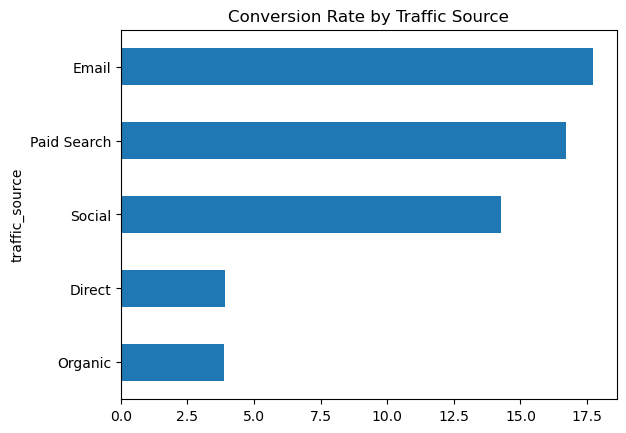

In [18]:
traffic_summary['Conversion_Rate'].sort_values().plot(kind='barh')
plt.title('Conversion Rate by Traffic Source')
plt.show()

## A/B Testing Analysis

In [20]:
views = df[df['event_type'] == 'view'].groupby('experiment_group').size()

purchases = df[df['event_type'] == 'purchase'].groupby('experiment_group').size()

experiment_conversion_rate = (purchases / views * 100).round(2)

print(experiment_conversion_rate)

experiment_group
Control       9.04
Variant_A    10.09
Variant_B    12.23
dtype: float64


In [21]:
views = df[df['event_type']=='view'].groupby('experiment_group').size()
purchases = df[df['event_type']=='purchase'].groupby('experiment_group').size()

experiment_summary = pd.DataFrame({
    'Views': views,
    'Purchases': purchases
})

experiment_summary['Conversion_Rate'] = (
    experiment_summary['Purchases']
    / experiment_summary['Views']
    * 100
).round(2)

experiment_summary

,Views,Purchases,Conversion_Rate
experiment_group,,,
Control,628630,56855,9.04
Variant_A,208655,21045,10.09
Variant_B,206288,25227,12.23


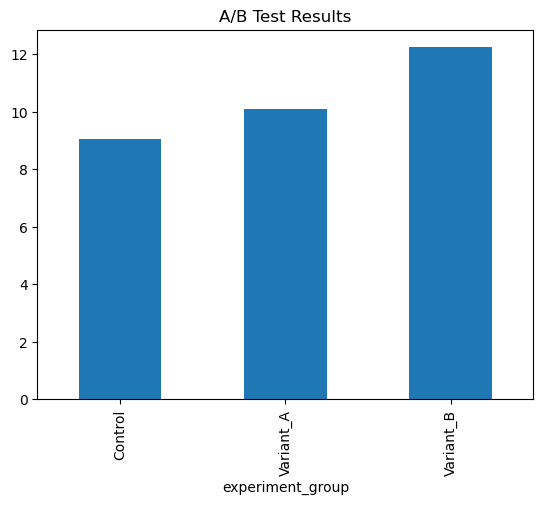

In [22]:
experiment_summary['Conversion_Rate'].plot(
    kind='bar'
)

plt.title('A/B Test Results')
plt.show()

In [23]:
control = 9.04
variant_b = 12.23

lift = ((variant_b - control) / control) * 100

round(lift,2)

35.29

## Device, Page Category and Session Analysis

In [25]:
views = df[df['event_type'] == 'view'].groupby('device_type').size()

purchases = df[df['event_type'] == 'purchase'].groupby('device_type').size()

device_conversion_rate = (purchases / views * 100).round(2)

print(device_conversion_rate)

device_type
desktop    9.87
mobile     9.88
tablet     9.94
dtype: float64


In [26]:
# purchase rate by device
views = df[df['event_type']=='view'].groupby('device_type').size()
purchases = df[df['event_type']=='purchase'].groupby('device_type').size()

purchase_rate = (purchases/views*100).round(2)
print(purchase_rate)

device_type
desktop    9.87
mobile     9.88
tablet     9.94
dtype: float64


In [27]:
# purchase rate by page category
views = df[df['event_type']=='view'].groupby('page_category').size()
purchases = df[df['event_type']=='purchase'].groupby('page_category').size()

purchase_rate = (purchases/views*100).round(2)
print(purchase_rate)

page_category
Cart         9.73
Checkout    10.00
Home         9.95
PDP          9.81
PLP          9.92
dtype: float64


In [28]:
session_funnel = pd.crosstab(
    df['session_bucket'],
    df['event_type']
)

session_funnel['Purchase_Rate'] = (
    session_funnel['purchase']
    / session_funnel['view']
    * 100
).round(2)

print(session_funnel[['Purchase_Rate']])

event_type      Purchase_Rate
session_bucket               
Short Session            9.86
Medium Session           9.91
Long Session             9.61


## Customer Retention Analysis

In [30]:
df['event_month'] = df['timestamp'].dt.to_period('M')

In [31]:
first_month = (
    df.groupby('customer_id')['event_month']
      .min()
      .reset_index()
)

first_month.columns = [
    'customer_id',
    'cohort_month'
]

In [32]:
df = df.merge(
    first_month,
    on='customer_id',
    how='left'
)

In [33]:
df['customer_type'] = np.where(
    df['event_month'] == df['cohort_month'],
    'New',
    'Returning'
)

In [34]:
retention = pd.crosstab(
    df['event_month'],
    df['customer_type']
)

print(retention)

customer_type    New  Returning
event_month                    
2021-01        56575          0
2021-02        29053      22019
2021-03        18968      37178
2021-04        10717      44094
2021-05         6332      50351
2021-06         3552      51070
2021-07         2098      54547
2021-08         1166      55564
2021-09          648      54091
2021-10          399      56258
2021-11          214      54756
2021-12          137      56369
2022-01           72      56258
2022-02           27      50995
2022-03           33      56495
2022-04           13      54999
2022-05            9      56669
2022-06           12      55260
2022-07            2      56469
2022-08            2      56886
2022-09            2      55059
2022-10            0      56762
2022-11            0      54793
2022-12            0      56695
2023-01            0      56847
2023-02            0      50961
2023-03            0      56424
2023-04            0      54752
2023-05            0      56580
2023-06 

In [35]:
retention['Retention_Rate'] = (
    retention['Returning']
    /
    (
        retention['New']
        + retention['Returning']
    )
    * 100
).round(2)

retention

customer_type,New,Returning,Retention_Rate
event_month,,,
2021-01,56575,0,0.00
2021-02,29053,22019,43.11
2021-03,18968,37178,66.22
2021-04,10717,44094,80.45
2021-05,6332,50351,88.83
2021-06,3552,51070,93.50
2021-07,2098,54547,96.30
2021-08,1166,55564,97.94
2021-09,648,54091,98.82


## Cohort Analysis

In [37]:
cohort_df = df.groupby(
    ['customer_id','event_month']
).size().reset_index(name='events')

cohort_df.head()

,customer_id,event_month,events
0,1,2021-06,1
1,1,2021-07,1
2,1,2021-10,1
3,1,2021-11,1
4,1,2021-12,3


In [38]:
cohort_df['cohort_month'] = (
    cohort_df.groupby('customer_id')['event_month']
    .transform('min')
)

In [39]:
cohort_df['cohort_index'] = (
    (cohort_df['event_month'].dt.year -
     cohort_df['cohort_month'].dt.year) * 12
    +
    (cohort_df['event_month'].dt.month -
     cohort_df['cohort_month'].dt.month)
)

In [40]:
cohort_counts = cohort_df.groupby(
    ['cohort_month','cohort_index']
)['customer_id'].nunique().reset_index()

In [41]:
cohort_pivot = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
cohort_month,,,,,,,,,,,,,,,,,,,,,
2021-01,43189.0,17253.0,18731.0,18203.0,18765.0,18103.0,18641.0,18629.0,18261.0,18585.0,...,18535.0,18235.0,18621.0,18128.0,18735.0,18769.0,18165.0,18556.0,18312.0,18643.0
2021-02,22756.0,9728.0,9615.0,9884.0,9642.0,9919.0,9904.0,9534.0,9857.0,9587.0,...,9537.0,9761.0,9620.0,9941.0,9864.0,9594.0,9852.0,9551.0,9857.0,NaN
2021-03,14569.0,6100.0,6200.0,6089.0,6350.0,6340.0,6176.0,6274.0,6195.0,6251.0,...,6315.0,6129.0,6281.0,6332.0,6232.0,6224.0,6133.0,6353.0,NaN,NaN
2021-04,8220.0,3547.0,3465.0,3531.0,3650.0,3477.0,3602.0,3497.0,3510.0,3565.0,...,3483.0,3506.0,3537.0,3425.0,3520.0,3423.0,3555.0,NaN,NaN,NaN
2021-05,4836.0,1997.0,2142.0,2059.0,1988.0,2033.0,2061.0,2081.0,2055.0,1979.0,...,2129.0,2114.0,2056.0,2086.0,2068.0,2118.0,NaN,NaN,NaN,NaN


In [42]:
cohort_size = cohort_pivot[0]

retention_matrix = cohort_pivot.divide(
    cohort_size,
    axis=0
) * 100

retention_matrix.round(2).head()

cohort_index,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
cohort_month,,,,,,,,,,,,,,,,,,,,,
2021-01,100.0,39.95,43.37,42.15,43.45,41.92,43.16,43.13,42.28,43.03,...,42.92,42.22,43.12,41.97,43.38,43.46,42.06,42.96,42.40,43.17
2021-02,100.0,42.75,42.25,43.43,42.37,43.59,43.52,41.90,43.32,42.13,...,41.91,42.89,42.27,43.69,43.35,42.16,43.29,41.97,43.32,NaN
2021-03,100.0,41.87,42.56,41.79,43.59,43.52,42.39,43.06,42.52,42.91,...,43.35,42.07,43.11,43.46,42.78,42.72,42.10,43.61,NaN,NaN
2021-04,100.0,43.15,42.15,42.96,44.40,42.30,43.82,42.54,42.70,43.37,...,42.37,42.65,43.03,41.67,42.82,41.64,43.25,NaN,NaN,NaN
2021-05,100.0,41.29,44.29,42.58,41.11,42.04,42.62,43.03,42.49,40.92,...,44.02,43.71,42.51,43.13,42.76,43.80,NaN,NaN,NaN,NaN


## Business Recommendations

### Traffic Sources
- Email delivers the highest conversion rate and should receive additional marketing investment.
- Organic generates significant traffic but converts poorly, indicating landing page or targeting issues.

### A/B Testing
- Variant B outperforms both Control and Variant A.
- Root Cause: The new experience increases the likelihood of users completing a purchase.
- Recommendation: Deploy Variant B to all users.

### Funnel Optimization
- Most users drop before purchase.
- Root Cause: Friction between product discovery and checkout.
- Recommendation: Improve checkout flow, retarget cart abandoners, and optimize product pages.

### Retention
- Cohort analysis shows customers continue returning after acquisition.
- Recommendation: Strengthen retention campaigns such as email nurturing, loyalty programs, and personalized offers.


## Conclusion

This analysis identified Email as the highest-converting acquisition channel and Variant B as the best-performing experiment. Funnel analysis revealed significant drop-off before purchase, highlighting an opportunity to improve the checkout journey. Retention and cohort analysis showed that a meaningful portion of customers return after acquisition, indicating healthy long-term engagement. Based on these findings, the business should scale Email marketing, deploy Variant B, optimize funnel bottlenecks, and invest in retention initiatives to maximize growth and revenue.


## Next Step

Export to csv format for PowerBI Analysis.

In [46]:
# df.to_csv('marketing_growth_cleaned.csv',index=False)